# Theory:
* Making a Regressoin Tree, by checking division between every data point and finding RMSE between avg value of left and right node and actual values, then choosing the split with least RMSE and thus forming a division.
* This is done recursively

### Base condition for Recusion:
* If leaf nodes are pure, no more division is possible.
* Other stopping criterion are met (e.g. max depth).

##### Implementing: [Video](https://www.youtube.com/watch?v=g9c66TUylZ4&list=PLN9DbzNoozxbIClspO-CCaBPkem6SWBnH)

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

%matplotlib inline

In [2]:
# Load the data
train = pd.read_csv('../data/leaf-classification/train.csv')
test = pd.read_csv('../data/leaf-classification/test.csv')
X = train.drop(columns=['species', 'id', 'margin1']).values
y = train['margin1'].values

# Train-Validation Split
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=123)

X_train.shape, X_valid.shape, y_train.shape, y_valid.shape

((792, 191), (198, 191), (792,), (198,))

### Analyzing the same thing using XGBoost:

In [3]:
from xgboost import XGBRegressor as m
from sklearn.metrics import mean_squared_error
model = m(random_state=123)
model.fit(X_train, y_train)

y_pred = model.predict(X_valid)
rmse = np.sqrt(np.mean(np.square(y_valid- y_pred)))
(f"RMSE: {rmse}")

'RMSE: 0.008020571776182688'

In [4]:
np.sqrt(np.mean(np.square(y - np.mean(y)))) # Average would have given 0.019 std, while we are getting 0.008 RMSE

np.float64(0.019729031619523132)

### Building Regression Tree

In [5]:
class Node:
    def __init__(self, feature_idx=None, threshold=None, info_gain=None, left=None, right=None, value=None):
        # A Node can either be a Decision Node or a Pure Node
        
        # Decision Node
        self.feature_idx = feature_idx
        self.threshold = threshold
        self.info_gain = info_gain
        self.left = left
        self.right = right

        # Leaf Node
        self.value = value

In [6]:
class RegressionTree:
    def __init__(self, min_samples_split=2, max_depth=2):
        # Min Samples for splitting to occur
        self.min_samples_split=min_samples_split
        # Max depth for base case and preventing overfitting
        self.max_depth = max_depth

    def build_tree(self, X, y, curr_depth=0):
        n_samples, n_features = X.shape

        # Must not be base condition 
        if n_samples >= self.min_samples_split and curr_depth < self.max_depth:
            best_split = self.best_split(X, y)

            left_node = self.build_tree(best_split["left_X"], best_split["left_y"], curr_depth + 1)
            right_node = self.build_tree(best_split["right_X"], best_split["right_y"], curr_depth + 1)

            return Node(best_split["feature_idx"], best_split["threshold"], best_split["loss"], left_node, right_node)

        # Returning a Pure Node with AVG value
        return Node(value=np.mean(y))

    # Can be Vectorized as well
    def predict(self, X):
        predictions = [self.predict_class(row, self.root) for row in X]
        return predictions

    def predict_class(self, x, node):
        # Leaf Node: Base case
        if node.value is not None:
            return node.value
        # Decision Node
        feature_value = x[node.feature_idx] 
        if feature_value <= node.threshold:
            return self.predict_class(x, node.left)
        else:
            return self.predict_class(x, node.right)

    def fit(self, X, y):
        self.root = self.build_tree(X, y)

In [7]:
def best_split(self, X, y):
    b_split = {
        "feature_idx": None,
        "threshold": None,
        "loss": float('inf'),
        "left_X": None,
        "left_y": None,
        "right_X": None,
        "right_y": None
    }

    n_feature = X.shape[-1]

    # Trying every possible feature x with every possible threshold to break and find resulting purity
    for feature_idx in range(n_feature):
        feature_values = X[:, feature_idx]
        thresholds = np.unique(feature_values)

        for threshold in thresholds:
            mask = X[:, feature_idx] <=threshold
            left_X = X[mask]
            left_y = y[mask]
            right_X = X[~mask]
            right_y = y[~mask]

            if len(left_y) and len(right_y):
                loss = np.sum(np.square(left_y - np.mean(left_y))) + np.sum(np.square(right_y - np.mean(right_y))) 

                if loss < b_split["loss"]:
                    b_split["feature_idx"] = feature_idx
                    b_split["threshold"] = threshold
                    b_split["loss"] = loss
                    b_split["left_X"] = left_X
                    b_split["left_y"] = left_y
                    b_split["right_X"] = right_X
                    b_split["right_y"] = right_y

    return b_split

RegressionTree.best_split = best_split

In [8]:
def best_split(self, X, y):
    b_split = {
        "feature_idx": None,
        "threshold": None,
        "loss": float('inf'),
        "left_X": None,
        "left_y": None,
        "right_X": None,
        "right_y": None
    }


    for feature_idx in range(X.shape[-1]):

        # Making all masks of feature_idx over all possible thresholds
        thresholds = np.unique(X[:, feature_idx], axis=0)                   # (thresholds,)
        left_mask = X[:, feature_idx].reshape(-1, 1) <= thresholds          # (rows, 1) <= (thresholds) = (rows, thresholds)

        y_reshaped = y.reshape(-1, 1)

        left_vals = left_mask * y_reshaped                                  # (rows, thresholds) * (rows, 1) = (rows, thresholds)
        right_vals = ~left_mask * y_reshaped                                  

        # Finding Sum of Squared Error
        del_left = np.square(left_vals - np.mean(left_vals, axis=0))         # (rows, thresholds)
        del_right = np.square(right_vals - np.mean(right_vals, axis=0))
        loss = np.sum(del_right * ~left_mask, axis=0) + np.sum(del_left * left_mask, axis=0)          # (thresholds)

        best_thresh_idx = np.argmin(loss)
        winning_mask = left_mask[:, best_thresh_idx]

        if winning_mask.sum() > 0 and (~winning_mask).sum() > 0:
            if loss[best_thresh_idx] < b_split["loss"]:
                b_split["feature_idx"] = feature_idx
                b_split["threshold"] = thresholds[best_thresh_idx]
                b_split["loss"] = loss[best_thresh_idx]
                b_split["left_X"] = X[winning_mask]
                b_split["left_y"] = y[winning_mask]
                b_split["right_X"] = X[~winning_mask]
                b_split["right_y"] = y[~winning_mask]

    return b_split
RegressionTree.best_split = best_split

In [9]:
rt = RegressionTree(min_samples_split=7, max_depth=5)
s = time.time()
rt.fit(X_train, y_train)
e = time.time()

y_pred = rt.predict(X_valid)
rmse = np.sqrt(np.mean(np.square(y_valid- y_pred)))
(f"RMSE: {rmse}"), e - s

('RMSE: 0.013722467343624613', 1.1126329898834229)

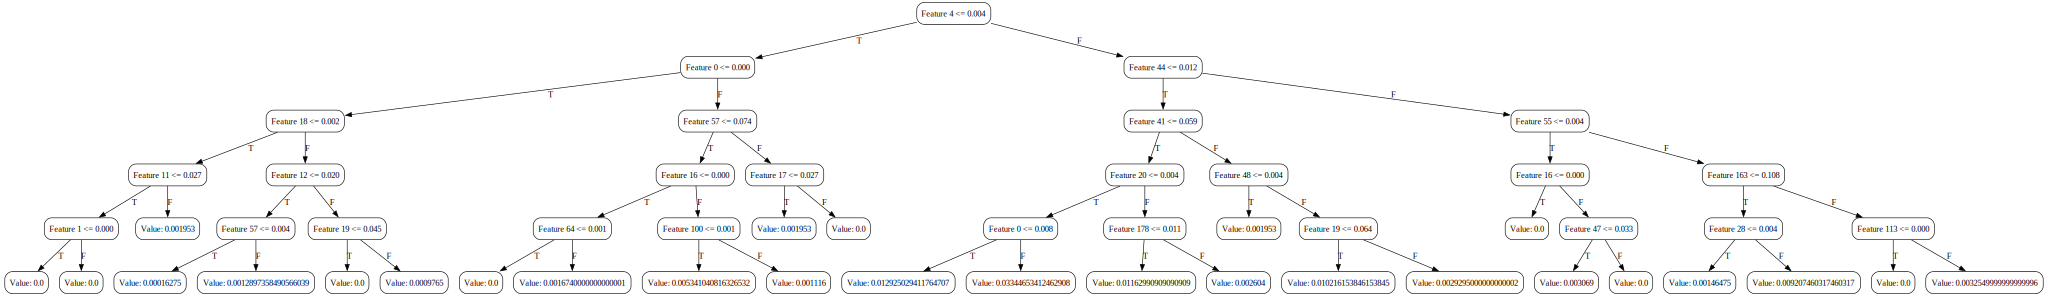

In [10]:
import graphviz
dot = graphviz.Digraph(node_attr={'shape': 'box', 'style': 'rounded'})
count = [0]

def get_graph(node):
    uid = str(count[0])
    count[0] += 1

    # Leaf Node
    if node.value is not None:
        dot.node(uid, f'Value: {node.value}')
        
    # Decision Node
    else:
        dot.node(uid, f'Feature {node.feature_idx} <= {node.threshold:.3f}')
        if node.left: dot.edge(uid, get_graph(node.left), "T")
        if node.right: dot.edge(uid, get_graph(node.right), "F")
    return uid
        
get_graph(rt.root)
dot